# Dull-Roar 🐢
### "Boring stocks quietly beat exciting ones" — the most-cited free lunch in finance. Can you actually eat it?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free alpha?: Beta-tilt](https://img.shields.io/badge/Free_alpha%3F-Beta--tilt-8b949e?style=flat-square)

Here's one of the great counter-intuitions in markets, and it's *almost* true. Sort every stock by how wild it's been and — the textbooks say — the **calm** ones go on to earn a *better risk-adjusted return* than the **wild** ones. More risk is supposed to mean more reward; the low-volatility anomaly says the opposite, and decades of academic data back it (Ang–Hodrick–Xing–Zhang 2006; Baker–Bradley–Wurgler 2011; Frazzini–Pedersen 2014). It's the idea behind every "min-vol" fund you've seen advertised.

This is the first idea we've pulled from a *book* — Kakushadze & Serur's *151 Trading Strategies*, strategy #3.4 — and it's a perfect desk specimen: a real, famous effect with a much bigger promise bolted on top. We'll do two things. First, **prove our machinery works** on a synthetic market where we *secretly bake the anomaly in* — so you can watch the tools find it, and watch them find *nothing* when we switch it off. Then we point the exact same tools at the **real S&P 500** — and discover the calm-beats-wild edge has quietly gone missing.

> 📓 **This is the plain-language layer.** Want the beta-neutral BAB regression, the HAC *t*-stats and the borrow-cost break-even? That's the companion notebook, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** An educational, reproducible research tool: every chart below is generated by the code beside it. The reproducible core runs on a **synthetic** universe where we *bake in* a known anomaly — so the real-market numbers (quoted from [`../docs/results.md`](../docs/results.md)) are a measurement, not a hope. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (dull_roar/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from dull_roar import data, sort, strategy, decompose, extension

# Offline synthetic cross-section: a single-factor universe with a BAKED-IN flat security-market line
# (low-beta names carry +alpha, high-beta -alpha -- the Frazzini-Pedersen mechanism), idio vol scaling
# with beta so a total-vol sort is a clean beta sort. The NULL (sml_slope=0) is textbook CAPM: alpha=0
# everywhere, so a vol sort must earn nothing. The real S&P 500 verdict is in ../docs/results.md.
panel, market, truth = data.synthetic_panel(seed=18)                       # the anomaly tape
panel0, market0, _   = data.synthetic_panel(sml_slope=0.0, seed=18)        # the fair-CAPM null
print(f"{truth.n_stocks} stocks x {truth.n_bars} days | baked low-minus-high alpha spread "
      f"{truth.annual_sml_alpha_spread:+.1%}/yr | null per-stock Sharpe {truth.null_stock_sharpe:+.2f}")


200 stocks x 4032 days | baked low-minus-high alpha spread +6.4%/yr | null per-stock Sharpe +0.32


## The answer first 🎯

| What we asked | The honest answer |
|---|---|
| Do calm stocks *really* out-earn wild ones, risk-adjusted? | 🟡 **In theory, yes; lately, no.** Decades of academic data say yes — but on the **modern S&P 500** the line is flat. |
| Is the clean version tradable? | 🚫 **No.** The proper, beta-neutral form needs you to **short** the wild stocks — the very names that are expensive or impossible to borrow. |
| What about just *buying* the calm stocks? | ⚪ **That's mostly low beta** — you're running less market risk, not finding free money. Lever it back up and the 'edge' fades. |
| So is it a free lunch? | 🚫 **No** — the one thing that survives is a *gentler ride* (shallower drawdowns), which is exactly what real min-vol funds quietly deliver. |

> Desk shorthand: **Signal `WEAK` · Tradability `MIRAGE` · Free alpha? `BETA-TILT`.** A real mechanism, an unharvestable promise. Let's see how we got there.

## 1 · The claim 📣

Stated at full strength: **risk is not rewarded the way the textbook says.** Rank stocks by past volatility, and the calm decile delivers a *higher Sharpe* than the wild decile. The leading explanation (Frazzini–Pedersen 2014) is elegant: lots of investors can't or won't use leverage, so to chase returns they pile into high-volatility, high-beta stocks instead — overpricing them — while the boring low-beta names are left cheap. The **security-market line** — the supposed straight-line trade-off between risk and reward — comes out *too flat*.

Let's make that concrete. On our synthetic market we've baked exactly this in. Sort the universe into ten volatility buckets and look at the Sharpe of each:

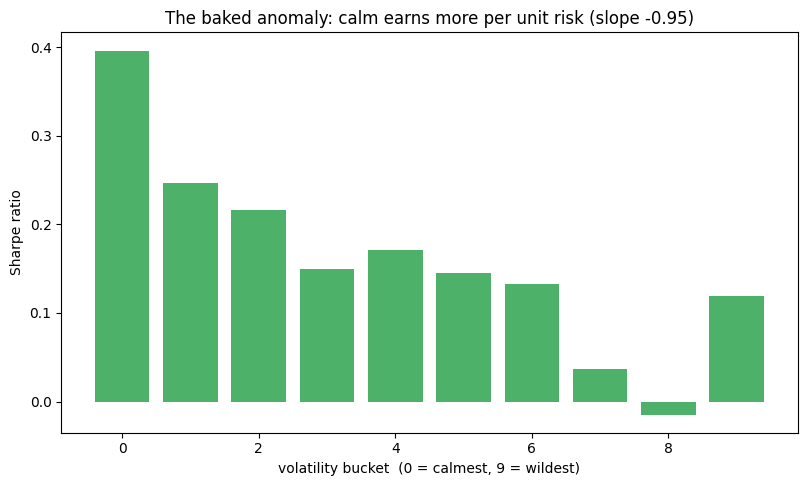

calmest-decile Sharpe +0.40  vs  wildest +0.12


In [2]:
sml = sort.security_market_line(panel)
tbl = sml['table']
fig, ax = plt.subplots()
ax.bar(tbl.index, tbl['sharpe'].values, color='#2ea44f', alpha=.85)
ax.set_xlabel('volatility bucket  (0 = calmest, 9 = wildest)'); ax.set_ylabel('Sharpe ratio')
ax.set_title(f"The baked anomaly: calm earns more per unit risk "
             f"(slope {sml['sharpe_vol_slope']:+.2f})")
plt.show()
print(f"calmest-decile Sharpe {sml['low_bucket_sharpe']:+.2f}  vs  wildest {sml['high_bucket_sharpe']:+.2f}")

A clean downward staircase: the calmer the bucket, the better the risk-adjusted return. *That* is the anomaly — and the whole question is whether it's real in the wild, and whether you could ever put it in your pocket.

## 2 · So what? 💰

If it holds, it breaks the first rule everyone learns: that to earn more you must risk more. You'd build a portfolio of *sleepy* stocks and beat the market on a risk-adjusted basis — higher Sharpe, shallower crashes, less stress. It's the closest thing to a free lunch the equity market offers, and it's why "minimum-volatility" and "low-beta" funds gather hundreds of billions of dollars. If the calm-beats-wild gap is real *and* harvestable, it's one of the most valuable facts in investing. Two very big 'if's.

## 3 · How we'd know 🔬

Five checks, decided up front:

1. **Is the security-market line really too flat?** Sort by vol; does Sharpe fall as vol rises?
2. **Does a clean (beta-neutral) long-short earn a real alpha** — return the market can't explain?
3. **Is buying the calm decile actually alpha, or just *less beta*?** Lever it to the market's risk and see what's left.
4. **Where does the effect live** — in the calm stocks you can buy, or the wild ones you'd have to *short*?
5. **Could you short them cheaply?** Charge a realistic borrow fee on the wild leg.

**The null:** on a fair-CAPM market (anomaly switched off), every one of these must come up empty. **What would make us cry 'mirage':** the edge needs the unshortable wild leg, *or* it's just a low-beta tilt, *or* it's simply absent on the real modern tape.

## 4 · The teardown 🔧

### 4a · First, prove the tools — find the anomaly we hid, then watch it vanish on the null
Same sort, two synthetic markets: the one with the baked anomaly, and a fair-CAPM **null** where risk *is* rewarded normally. If our tools are honest, the staircase should appear in one and flatten in the other.

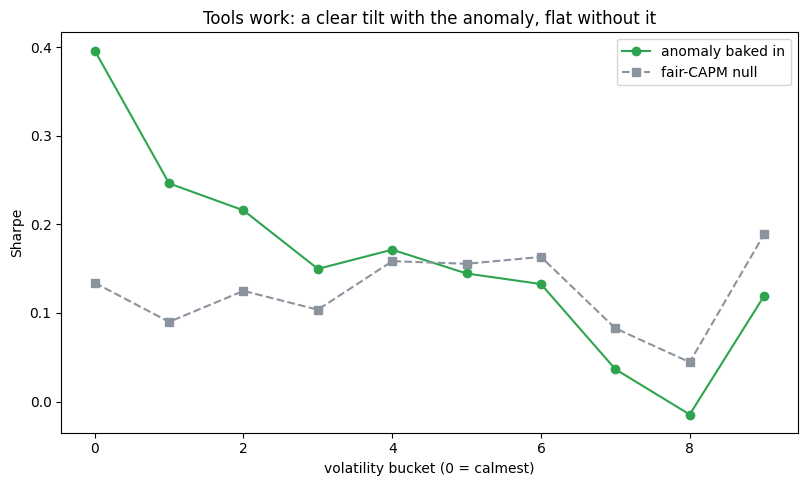

In [3]:
s1 = sort.security_market_line(panel)['table']['sharpe']
s0 = sort.security_market_line(panel0)['table']['sharpe']
fig, ax = plt.subplots()
ax.plot(s1.index, s1.values, 'o-', color='#2ea44f', label='anomaly baked in')
ax.plot(s0.index, s0.values, 's--', color='#8b949e', label='fair-CAPM null')
ax.set_xlabel('volatility bucket (0 = calmest)'); ax.set_ylabel('Sharpe'); ax.legend()
ax.set_title('Tools work: a clear tilt with the anomaly, flat without it')
plt.show()

### 4b · The clean way to harvest it — and the trap in the naive way
The obvious trade is dollar-neutral: buy the calm decile, short the wild one. But calm stocks are *low-beta* and wild stocks *high-beta*, so that book is secretly **short the market** — in a rising market the beta drag alone can sink it. The fix (Frazzini–Pedersen) is to **beta-neutralise**: scale each leg so the bet is purely calm-vs-wild, not down-on-the-market. Watch the difference on the anomaly tape:

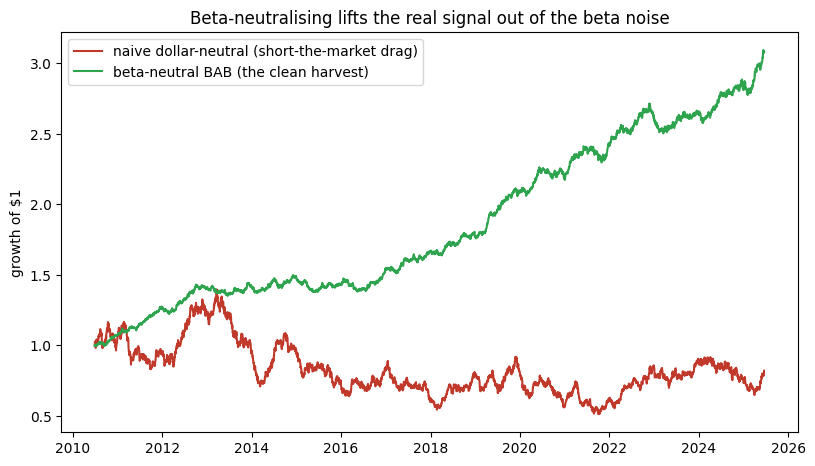

beta-neutral BAB alpha +7.4%/yr (t=+5.6), Sharpe +1.34 -- a real, market-independent edge on the baked tape.


In [4]:
b = strategy.build(panel, market=market, cost_bps=1.0)
naive = (b['low_only'] - b['high'])                      # dollar-neutral: structurally short beta
bab   = decompose.beta_neutral_bab(panel, market=market, cost_bps=1.0)
eq_naive = (1+naive).cumprod(); eq_bab = (1+bab['stream']).cumprod()
fig, ax = plt.subplots()
ax.plot(eq_naive.index, eq_naive.values, color='#c0392b', label='naive dollar-neutral (short-the-market drag)')
ax.plot(eq_bab.index, eq_bab.values, color='#2ea44f', label='beta-neutral BAB (the clean harvest)')
ax.set_ylabel('growth of $1'); ax.legend(); ax.set_title('Beta-neutralising lifts the real signal out of the beta noise')
plt.show()
print(f"beta-neutral BAB alpha {bab['alpha_ann_pct']:+.1f}%/yr (t={bab['alpha_t']:+.1f}), "
      f"Sharpe {bab['sharpe']:+.2f} -- a real, market-independent edge on the baked tape.")

### 4c · Is *buying* the calm stocks free money — or just less risk?
A min-vol fund is long-only. Its higher Sharpe could be genuine alpha, or it could simply be that it runs *less market risk* — a thing you could copy by holding the index and some cash. The test: measure the calm book's beta, then lever it back to the market's risk and see if any excess return survives.

In [5]:
tilt = decompose.beta_tilt_test(panel, market=market, cost_bps=1.0)
print(f"calm book beta = {tilt['low_beta']:.2f}  (well below 1 -> it runs less market risk)")
print(f"Sharpe vs market: {tilt['market_sharpe']:+.2f} -> {tilt['low_only_sharpe']:+.2f} "
      f"(gain {tilt['sharpe_gain']:+.2f})")
print(f"but levered back to the market's risk, the *excess* return is only "
      f"{tilt['excess_cagr_at_beta1_pct']:+.1f}%/yr -- the smaller, honest number.")

calm book beta = 0.47  (well below 1 -> it runs less market risk)
Sharpe vs market: +0.18 -> +0.57 (gain +0.39)
but levered back to the market's risk, the *excess* return is only +6.7%/yr -- the smaller, honest number.


On the synthetic tape there's still real alpha left over (we baked it in). Hold that thought — on the *real* market this is exactly where the story turns.

### 4d · The null collapses
Switch the anomaly off (fair-CAPM market) and re-run the clean harvest. If our machine is honest, the alpha must vanish.

In [6]:
bab0 = decompose.beta_neutral_bab(panel0, market=market0, cost_bps=1.0)
print(f"anomaly tape : beta-neutral alpha {decompose.beta_neutral_bab(panel, market=market)['alpha_ann_pct']:+.1f}%/yr")
print(f"fair-CAPM null: beta-neutral alpha {bab0['alpha_ann_pct']:+.1f}%/yr (t={bab0['alpha_t']:+.1f}) -- gone, as it must be.")

anomaly tape : beta-neutral alpha +7.4%/yr
fair-CAPM null: beta-neutral alpha -0.3%/yr (t=-0.2) -- gone, as it must be.


### 4e · Now the real market — and the twist
Tools proven, we point them at the **current S&P 500** (2010 onward). Here's what the same sort finds, quoted from [`../docs/results.md`](../docs/results.md):

- The security-market line is **flat** — slope **-0.07**, calm-decile Sharpe **+0.63** vs wild-decile **+0.59**. The staircase is gone.
- The clean beta-neutral long-short earns **-2.2%/yr** (t = **-0.4**) — indistinguishable from zero, and if anything *negative*.
- The calm book actually **trailed** the market (Sharpe +0.93 vs +1.03).
- Astonishingly, **81%** of what little spread exists sits in the *wild* leg — whose alpha was **+7.2%** (t +2.3). Over this decade the exciting stocks *won*.

The celebrated anomaly didn't survive contact with the modern large-cap tape.

## 5 · The verdict 🧾

- **The mechanism is real** — our control recovers a beta-neutral alpha at *t* ≈ 5.6, and the null is flat. The tools are sound.
- **But on the real S&P 500 it's absent** — flat SML, a -2.2%/yr beta-neutral alpha (t = -0.4). Real in the long-run literature, **decayed-to-gone** in the sample you'd actually trade.
- **What's left is a low-beta tilt**, not free alpha.

> **Signal `WEAK` · Tradability `MIRAGE` · Free alpha? `BETA-TILT`.** Why `WEAK` and not a flat `NONE`? Because the long-run effect and our control are unambiguously real — this modern, survivorship-biased window is where it fails, which is a fact about its *fragility*, not a clean refutation.

## 6 · Could you trade it? 💸

Three walls, any one fatal:

- **You'd have to short the wild stocks.** The clean edge lives in the high-vol leg (81% of it), and those names — small, lottery-like, heavily shorted — are exactly the expensive-or-impossible-to-borrow ones. On the real tape the dollar-neutral book is under water before the borrow even costs anything (break-even **0 bps**).
- **Buying calm is just low beta.** The long-only book's lift is mostly *less market risk* (beta 0.59); levered to the market's risk it adds a thin, insignificant **+2.1%/yr** (t +0.8).
- **It was absent when you'd have run it.** Over 2010–2026 the calm book trailed.

The one durable consolation is the *ride*, not the return:

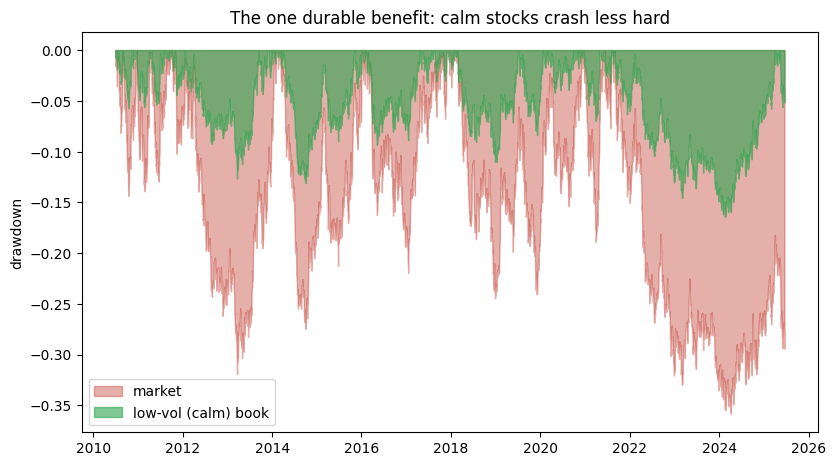

(Synthetic tape shown. On the REAL S&P 500 the worst drawdown goes -38% -> -34% -- the gentler ride min-vol funds actually sell.)


In [7]:
b = strategy.build(panel, market=market, cost_bps=1.0)
def dd(x): e=(1+x).cumprod(); return e/e.cummax()-1
fig, ax = plt.subplots()
ax.fill_between(b['market'].index, dd(b['market']).values, 0, alpha=.4, color='#c0392b', label='market')
ax.fill_between(b['low_only'].index, dd(b['low_only']).values, 0, alpha=.6, color='#2ea44f', label='low-vol (calm) book')
ax.set_ylabel('drawdown'); ax.legend(); ax.set_title('The one durable benefit: calm stocks crash less hard')
plt.show()
print('(Synthetic tape shown. On the REAL S&P 500 the worst drawdown goes -38% -> -34% -- the gentler ride min-vol funds actually sell.)')

> Tradability **`MIRAGE`** — the tradable anomaly needs a short you can't afford. "Free alpha?" **`BETA-TILT`** — buying calm is buying less beta, dressed up.

## 7 · Going further 🚪

- **We built the salvage case — "what if you only go long?"** The one slice needing no short is the long-only calm book. Worked complement (beat 7 of the quants notebook + [`../docs/extension.md`](../docs/extension.md)): on the real tape it's a thin, insignificant defensive tilt across *every* lookback and decile width we tried — lower beta, shallower drawdowns, no alpha. The salvage confirms the verdict.
- **Go back further, and include the dead.** Our sample is *current* S&P 500 since 2010 — a survivorship-biased, high-beta-friendly decade. The long-run anomaly lives in 1926-on, all-cap, *delisted-included* data. A fork that loads CRSP-style history could show the effect alive where ours is absent — and date when it faded.
- **Control for value & quality.** Much of low-vol's academic alpha overlaps cheap, profitable, defensive names. Does any survive once you net those out?

PRs welcome — resurrect the anomaly on honest long-run data, or pin down exactly when the crowd competed it away.